# Prototipo Qiskit: Grover de Umbral y Mínimo Dürr–Høyer (v3)

Objetivos:
- Detectar bombas sobre un umbral por variable (Grover con oráculo de umbral).
- Hallar la bomba más sana (mínimo, argmin) por variable con un bucle Dürr–Høyer robusto.

Notas:
- Variables normalizadas en [0, 1]; menor = más sano.
- Se usa un cálculo óptimo de iteraciones de Grover y varios intentos por ronda.
- Fijamos semilla y aumentamos shots para resultados más estables.
- Al final se muestra un histograma de resultados.

## ¿Qué hace el siguiente bloque?
El siguiente bloque deja listo el entorno para ejecutar la demostración. En el paper, la idea es repetir una búsqueda cuántica varias veces; aquí preparamos las herramientas para poder hacer esas repeticiones de forma controlada.

In [1]:
from math import ceil, log2, pi, sqrt, asin, floor
from collections import Counter
import random

from qiskit import QuantumCircuit, transpile

from qiskit_aer import Aer

# Semilla para reproducibilidad en este cuaderno
random.seed(0)
print("Qiskit backend cargado:", Aer)

Qiskit backend cargado: AerProvider


## ¿Qué hace el siguiente bloque?
Este bloque define ayudas sencillas para pasar de índices a bits y viceversa. Es útil porque, igual que en la descripción del paper, trabajamos con posiciones de una tabla y necesitamos reconocer correctamente qué posición fue encontrada.

In [ ]:
def numero_qubits_para_n(n_elementos: int) -> int:
    """Calcula el número mínimo de qubits necesarios para representar n_elementos."""
    return max(1, ceil(log2(max(1, n_elementos))))

def indice_a_bits(i: int, n_qubits: int):
    """Convierte un índice entero a una lista de bits de longitud n_qubits."""
    return [int(b) for b in format(i, f"0{n_qubits}b")]

def cadena_bits_a_indice(bs: str) -> int:
    # invierte la cadena porque Qiskit devuelve los bits en orden opuesto, endian little
    return int(bs[::-1], 2)

## ¿Qué hace el siguiente bloque?
Aquí se construye la búsqueda cuántica usada en la demo: primero se marcan los elementos que cumplen una condición y luego se amplifica su aparición. Esto sigue la subrutina de búsqueda que el paper usa para encontrar un índice mejor que el umbral actual.

In [ ]:
def puerta_oraculo_fase(n_indice: int, indices_marcados):
    """
    Devuelve un Gate que aplica un flip de fase a |i> para i en indices_marcados usando 
    un ancilla en |->.
    El circuito espera n_indice qubits de índice y 1 qubit ancilla al final.
    """
    circuito = QuantumCircuit(n_indice + 1, name="Oraculo")
    for idx in indices_marcados:
        bits = indice_a_bits(idx, n_indice)
        for qb, bit in enumerate(bits):
            if bit == 0:
                circuito.x(qb)
        circuito.mcx(list(range(n_indice)), n_indice)
        for qb, bit in enumerate(bits):
            if bit == 0:
                circuito.x(qb)
    return circuito.to_gate()

def puerta_difusora(n_indice: int):
    circuito = QuantumCircuit(n_indice, name="Difusora")
    circuito.h(range(n_indice))
    circuito.x(range(n_indice))
    if n_indice == 1:
        circuito.z(0)
    else:
        circuito.h(n_indice - 1)
        circuito.mcx(list(range(n_indice - 1)), n_indice - 1)
        circuito.h(n_indice - 1)
    circuito.x(range(n_indice))
    circuito.h(range(n_indice))
    return circuito.to_gate()

def iteraciones_optimas_grover(N: int, M: int) -> int:
    if M <= 0 or M > N:
        return 1
    theta = asin(sqrt(M / N))
    k = floor(pi / (4 * theta) - 0.5)
    return max(1, k)

def ejecutar_grover_umbral(
        indices_marcados,
        n_elementos: int,
        iteraciones: int = 1,
        tiros: int = 4096
    ):
    n_indice = numero_qubits_para_n(n_elementos)
    circuito = QuantumCircuit(n_indice + 1, n_indice, name="GroverUmbral")
    circuito.h(range(n_indice))
    circuito.x(n_indice)
    circuito.h(n_indice)
    oraculo = puerta_oraculo_fase(n_indice, indices_marcados)
    difusora = puerta_difusora(n_indice)
    for _ in range(iteraciones):
        circuito.append(oraculo, list(range(n_indice + 1)))
        circuito.append(difusora, list(range(n_indice)))
    circuito.measure(list(range(n_indice)), list(range(n_indice)))
    simulador = Aer.get_backend("qasm_simulator")
    circuito_transpilado = transpile(circuito, simulador)
    resultado = simulador.run(circuito_transpilado, shots=tiros).result()
    conteos = resultado.get_counts()
    return conteos, circuito


## Datos de ejemplo (sintético)
- Valores bajos son equipos sanos.
- Demostramos búsqueda de umbral (τ = 0.8) y mínimo.


Este bloque fija una tabla de ejemplo (las bombas y sus valores). En el paper, el problema parte de una tabla desordenada y el objetivo es localizar el índice del valor mínimo; aquí preparamos exactamente ese escenario, pero con datos sintéticos.

In [4]:
ids_bombas = [f"P{i:03d}" for i in range(8)]
tiempo_uso  = [0.21, 0.18, 0.11, 0.09, 0.85, 0.67, 0.44, 0.32]
corriente_maxima = [0.10, 0.52, 0.33, 0.01, 0.72, 0.64, 0.28, 0.41]
vibracion   = [0.03, 0.14, 0.59, 0.20, 0.22, 0.47, 0.18, 0.35]
N = len(ids_bombas)
tau = 0.1


## Grover de umbral (candidatos a mantenimiento)


## ¿Qué hace el siguiente bloque?
Este bloque prueba la búsqueda de candidatos que superan un umbral. Es la misma idea base del paper: marcar un subconjunto y usar la búsqueda cuántica para encontrar, con alta probabilidad, un elemento dentro de ese subconjunto.

In [5]:
valores = corriente_maxima
marcados = [i for i, v in enumerate(valores) if v >= tau]
M = len(marcados)
print("Índices marcados (v >= tau):", marcados)
if M == 0:
    print("No hay bombas sobre el umbral.")
else:
    k = iteraciones_optimas_grover(N, M)
    conteos, circuito = ejecutar_grover_umbral(marcados, N, iteraciones=k, tiros=4096)
    print("Iteraciones Grover:", k)
    print("Resultados principales:")
    for bitstring, c in Counter(conteos).most_common(8):
        idx = cadena_bits_a_indice(bitstring)
        print(bitstring, "-> índice", idx, ids_bombas[idx], "conteo", c)


Índices marcados (v >= tau): [0, 1, 2, 4, 5, 6, 7]
Iteraciones Grover: 1
Resultados principales:
110 -> índice 3 P003 conteo 3221
001 -> índice 4 P004 conteo 136
010 -> índice 2 P002 conteo 135
011 -> índice 6 P006 conteo 124
100 -> índice 1 P001 conteo 123
101 -> índice 5 P005 conteo 121
111 -> índice 7 P007 conteo 121
000 -> índice 0 P000 conteo 115


## Mínimo Dürr–Høyer robusto (bomba más sana)


## ¿Qué hace el siguiente bloque?
Este bloque implementa el ciclo principal de Dürr–Høyer: se parte de un índice inicial, se busca uno mejor (más pequeño) y, si aparece, se actualiza el umbral. Se repite hasta que ya no hay mejora clara, tal como describe el paper.

In [ ]:
from collections import Counter

def cadena_bits_a_indice(bs: str) -> int:
    return int(bs[::-1], 2)

def dh_min_indice(
        valores,
        tiros=8192, 
        max_rounds=8,
        tries_per_round=5,
        topk=3,
        use_bbht=True
    ):
    """
    - Acumula cuentas de varios intentos por ronda (Counter).
    - Selecciona entre los top-k más frecuentes el índice con menor valor (más sano).
    - Si no mejora, opción de intento aleatorio (BBHT).
    """
    N = len(valores)
    actual = random.randrange(N)
    valor_actual = valores[actual]
    historia = [(actual, valor_actual)]

    for _ in range(max_rounds):
        marcados = [j for j, v in enumerate(valores) if v < valor_actual]
        if not marcados:
            break
        M = len(marcados)

        # 1) Agregar evidencia de varios intentos
        agregador = Counter()
        k = iteraciones_optimas_grover(N, M)
        for _ in range(tries_per_round):
            conteos, _ = ejecutar_grover_umbral(marcados, N, iteraciones=k, tiros=tiros)
            # convertir claves a índices correctos y acumular
            mapeado = {cadena_bits_a_indice(bs): c for bs, c in conteos.items()}
            agregador.update(mapeado)

        if agregador:
            # top-k por frecuencia (cuentas), luego elige el de menor valor
            top = sorted(
                agregador.items(), key=lambda x: x[1], reverse=True
                )[:max(1, topk)]
            cand_idx = min((i for i, _ in top), key=lambda i: valores[i])
            cand_val = valores[cand_idx]
            historia.append((cand_idx, cand_val))
            if cand_val < valor_actual:
                actual, valor_actual = cand_idx, cand_val
                continue  # siguiente ronda

        # 2) Fallback BBHT (opcional)
        if use_bbht:
            k_max = iteraciones_optimas_grover(N, max(1, M))
            k_rand = random.randint(0, max(1, k_max))
            conteos, _ = ejecutar_grover_umbral(
                marcados, N, iteraciones=max(1, k_rand), tiros=tiros
                )
            mapeado = {cadena_bits_a_indice(bs): c for bs, c in conteos.items()}
            if mapeado:
                # toma el índice más frecuente en este intento aleatorio
                cand_idx = max(mapeado.items(), key=lambda x: x[1])[0]
                cand_val = valores[cand_idx]
                historia.append((cand_idx, cand_val))
                if cand_val < valor_actual:
                    actual, valor_actual = cand_idx, cand_val
                    continue

        # sin mejora, detener
        break

    return actual, historia

# Ejecutar prueba de mínimo sobre tiempo_uso
valores = tiempo_uso
idx_q, hist = dh_min_indice(
    valores,
    tiros=8192,
    max_rounds=8,
    tries_per_round=10,
    topk=5,
    use_bbht=False
    )
idx_classico = min(range(N), key=lambda i: valores[i])
print("Índice cuántico (argmin):", idx_q, ids_bombas[idx_q],
      "valor=", valores[idx_q])
print("Índice clásico (argmin):", idx_classico, ids_bombas[idx_classico], 
      "valor=", valores[idx_classico])
print("¿Coinciden?", "Sí" if idx_q == idx_classico else "No")
print("Historia (índice, valor):", hist)

Índice cuántico (argmin): 3 P003 valor= 0.09
Índice clásico (argmin): 3 P003 valor= 0.09
¿Coinciden? Sí
Historia (índice, valor): [(6, 0.44), (0, 0.21), (3, 0.09)]


## ¿Qué hace el siguiente bloque?
Este bloque repite muchas veces la búsqueda del mínimo para medir cuántas veces coincide con el resultado clásico. Esto está en línea con la observación final del paper: repetir ejecuciones aumenta la confianza en obtener el mínimo correcto. Además así podemos ver la comparación entre el resultado clásico y el cuántico en un histograma.

Clásico (argmin): idx=3 (P003) valor=0.090
Ensayos: 120 | Coinciden: 94 | No coinciden: 26 | Acierto: 78.3%


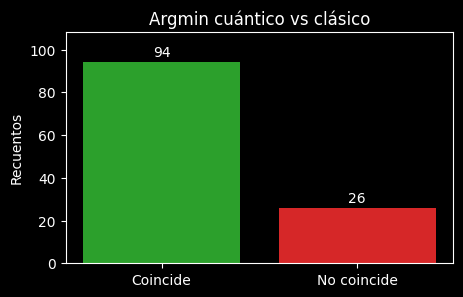

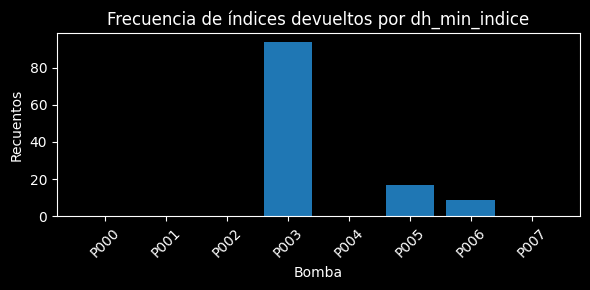

In [ ]:
# Iteraciones para estimar tasa de aciertos del argmin cuántico
import random
import matplotlib.pyplot as plt
from collections import Counter

# Parámetros
valores = tiempo_uso  # cambia a corriente_maxima, vibracion, etc. si quieres
max_rounds = 8
tries_per_round = 10
tiros = 8192
trials = 120  # bajamos para acelerar la ejecución con parámetros más costosos

# Índice clásico de referencia
N = len(valores)
idx_classico = min(range(N), key=lambda i: valores[i])

# Ejecutar múltiples veces
hits = 0
misses = 0
q_indices = []

# Opcional: fija semilla para reproducibilidad de este bloque
# random.seed(1)

for _ in range(trials):
    idx_q, _ = dh_min_indice(
        valores,
        tiros=tiros,
        max_rounds=max_rounds,
        tries_per_round=tries_per_round
        )
    q_indices.append(idx_q)
    if idx_q == idx_classico:
        hits += 1
    else:
        misses += 1

print(f"Clásico (argmin): idx={idx_classico} ({ids_bombas[idx_classico]}) valor={valores[idx_classico]:.3f}")
print(f"Ensayos: {trials} | Coinciden: {hits} | No coinciden: {misses} | Acierto: {100*hits/trials:.1f}%")

# Histograma de coincidencias vs no
plt.figure(figsize=(5,3))
plt.bar(['Coincide','No coincide'], [hits, misses], color=['tab:green','tab:red'])
plt.title('Argmin cuántico vs clásico')
plt.ylabel('Recuentos')
for x, y in zip(['Coincide','No coincide'], [hits, misses]):
    plt.text(x, y + max(1, trials*0.01), f"{y}", ha='center', va='bottom')
plt.ylim(0, max(hits, misses)*1.15 if trials>0 else 1)
plt.show()

# (Opcional) Distribución de índices cuánticos devueltos
plt.figure(figsize=(6,3))
counts = Counter(q_indices)
plt.bar([ids_bombas[i] for i in range(N)], [counts.get(i,0) for i in range(N)],
        color='tab:blue')
plt.title('Frecuencia de índices devueltos por dh_min_indice')
plt.ylabel('Recuentos')
plt.xlabel('Bomba')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conculsiones
- El prototipo muestra cómo implementar las ideas de Grover y Dürr–Høyer para encontrar mínimos en una tabla.
- Repetir la búsqueda cuántica mejora la confianza en el resultado, tal como se observa en el paper.
- El histograma final permite comparar visualmente los resultados clásicos y cuánticos, mostrando la eficacia del enfoque.

Para mejorar:
- Implementar un oráculo más general que no dependa de valores embebidos.
- Explorar el impacto de diferentes números de iteraciones y shots en la precisión del resultado.
- Considerar casos con más bombas y variables para ver cómo escala el algoritmo.

En resumen, este prototipo es una base sólida para experimentar con las ideas del paper y entender cómo funcionan los algoritmos de búsqueda cuántica en la práctica. Sin embargo, aplicarlo a casos más complejos como el de las bombas reales requerirá adaptar el oráculo y posiblemente optimizar la implementación para manejar más datos, o bien buscar otro algortimo de búsqueda de mínimos más adecuado para este caso.